In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END


In [ ]:
class AgentState:
    number1:int
    number2:int
    number3:int
    number4:int
    operation1:str
    operation2:str
    result:int
    result2:int


In [21]:
def adder1(state:AgentState) -> AgentState:
    state["result1"] = state["number1"] + state["number2"]
    return state

def subtractor1(state:AgentState) -> AgentState:
    state["result1"] = state["number1"] - state["number2"]
    return state

def adder2(state:AgentState) -> AgentState:
    state["result2"] = state["number3"] + state["number4"]
    return state

def subtractor2(state:AgentState) -> AgentState:
    state["result2"] = state["number3"] - state["number4"]
    return state

def router1(state:AgentState):
    if state["operation"] == "+":
        return "addition1"

    else:
        return "substraction1"

def router2(state:AgentState):
    if state["operation"] == "+":
        return "addition2"
    
    else:
        return "substraction2"

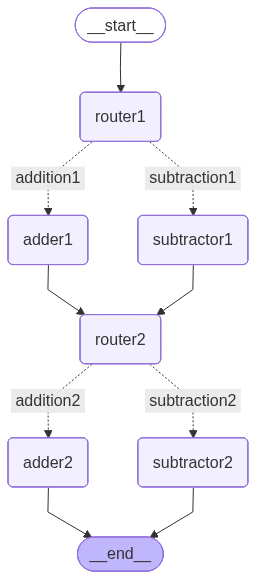

In [26]:
graph = StateGraph(AgentState)

graph.add_node("adder1",adder1)
graph.add_node("subtractor1",subtractor1)
graph.add_node("router1",lambda state:state)
graph.add_node("adder2",adder2)
graph.add_node("subtractor2",subtractor2)
graph.add_node("router2",lambda state:state)

graph.add_edge(START,"router1")

graph.add_conditional_edges("router1",
                            router1,
               {
                "addition1":"adder1",
                "subtraction1":"subtractor1"   
               }
               )

graph.add_edge("adder1","router2")
graph.add_edge("subtractor1","router2")



graph.add_conditional_edges("router2",
                            router2,
               {
                "addition2":"adder2",
                "subtraction2":"subtractor2"   
               }
               )


graph.add_edge("adder2",END)
graph.add_edge("adder2",END)

app = graph.compile()
app